In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [6]:
# STEP 1: SENTENCES (3 TOPICS)
# =========================================
sentences = [
    # Cricket
    "The batsman scored a century in the final match",
    "The bowler delivered a perfect yorker to take a wicket",
    "India won the cricket match by 5 runs",
    
    # Cooking
    "The chef prepared a delicious pasta with cheese",
    "Baking a cake requires precise measurements of ingredients",
    "Frying vegetables in olive oil enhances the flavor",
    
    # Cybersecurity
    "Strong passwords help protect against hacking attempts",
    "Encryption secures sensitive data from unauthorized access",
    "Phishing attacks trick users into revealing personal information",
    
    # Extra sentence (10 total)
    "Firewalls prevent unauthorized access to computer networks"
]

In [8]:
# STEP 2: LOAD MODEL
# =========================================
model = SentenceTransformer('all-MiniLM-L6-v2')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
embeddings = model.encode(sentences)
print("Embeddings generated")

Embeddings generated


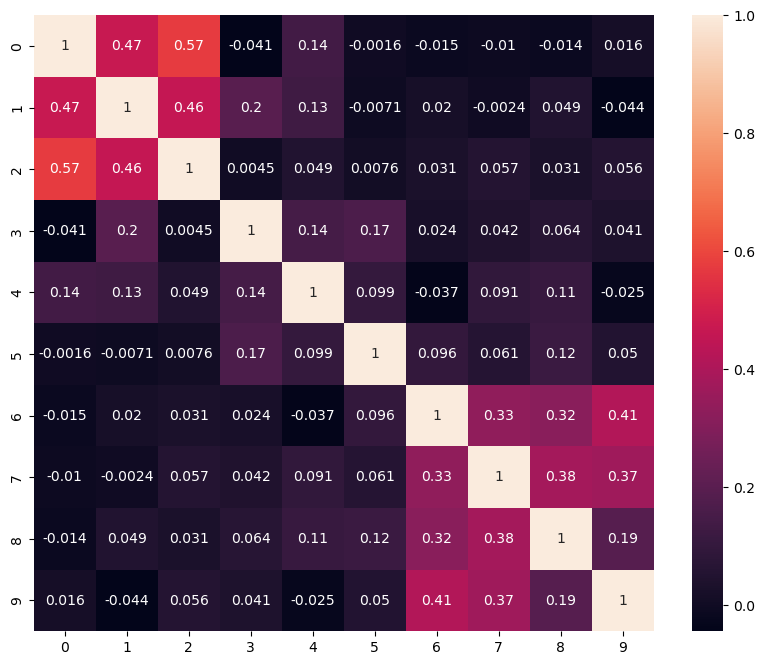

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True)
plt.show()

In [11]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]


In [12]:
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 Similar Sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 Similar Sentences:

Sentence: The bowler delivered a perfect yorker to take a wicket
Similarity Score: 0.6836

Sentence: India won the cricket match by 5 runs
Similarity Score: 0.5856

